In [1]:
import utils as utils
import torch.optim as optim
import torch
from IPython.display import Audio
import NeuralNet
from torchsummary import summary
from Hyperparams import Hyperparams as hp
import torch.nn as nn

In [2]:
VCTK_PATH = "dataset/clear"
# VCTK_PATH = "dataset/clear/"
DEMAND_PATH = "dataset/noise"
signal_length = 5

In [ ]:


neuralNet = utils.NeuralNetwork(
                                neural_net=NeuralNet.DenoisingNet(),
                                optimizer=optim.Adam,
                                loss_fn = torch.nn.MSELoss(),
                                noisy_dir=DEMAND_PATH,
                                clean_dir=VCTK_PATH
                                )
dataset = neuralNet.get_dataset()

len(self.clean_files) = 17884
len(self.noisy_files) = 80
Using device: cuda


In [4]:
mix_spector, clean_spector, noisy_spector, clean_audio, noisy_audio, mix_audio =  dataset.get_example()

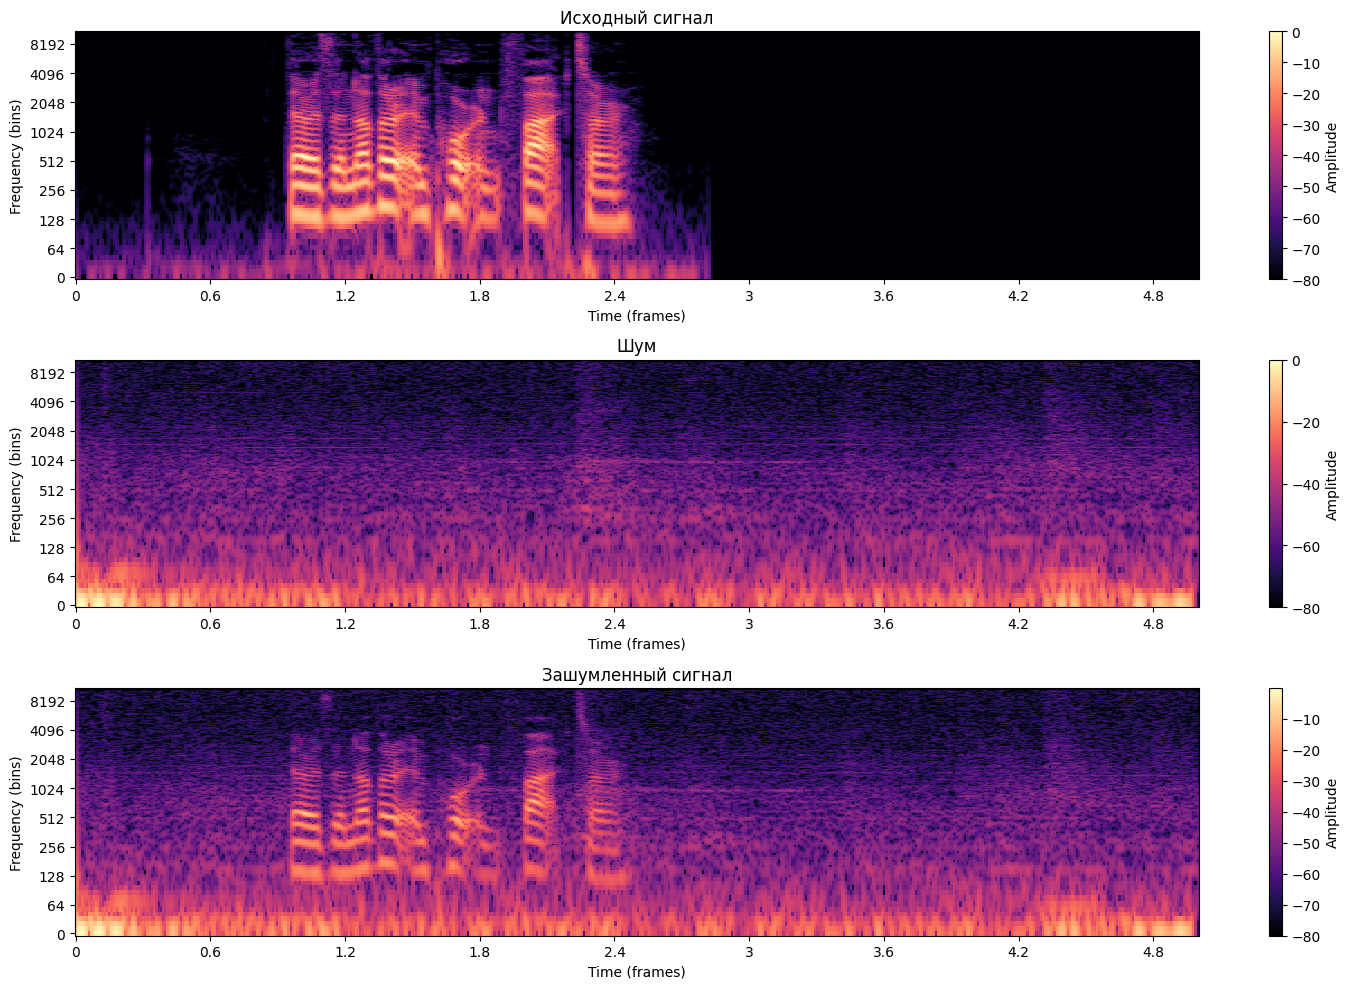

In [5]:
dataset.draw_spectogram((clean_spector[1], "Исходный сигнал"), (noisy_spector[1], "Шум"),  (mix_spector[1], "Зашумленный сигнал"))

In [ ]:

neuralNet.study(hp.epochs, validation_repeate=0.1, save_best_model=True, model_path="D:/NeuralNetwork/project/checkPoint")

Epoch 1/100, Time = 5511.803639888763 Train Loss: 0.2648, Validation Loss: 0.1783
	Checkpoint saved at epoch 2
	Best model saved with Validation Loss: 0.1783
Epoch 2/100, Time = 944.8270306587219, Train Loss: 0.1694
Epoch 3/100, Time = 909.854496717453, Train Loss: 0.1589
Epoch 4/100, Time = 911.0062916278839, Train Loss: 0.1592
Epoch 5/100, Time = 909.4915618896484, Train Loss: 0.1492
Epoch 6/100, Time = 909.90758061409, Train Loss: 0.1473
Epoch 7/100, Time = 912.1652805805206, Train Loss: 0.1458
Epoch 8/100, Time = 911.2365186214447, Train Loss: 0.1272
Epoch 9/100, Time = 908.6068661212921, Train Loss: 0.1476
Epoch 10/100, Time = 907.380063533783, Train Loss: 0.1330
Epoch 11/100, Time = 5572.717192649841 Train Loss: 0.1293, Validation Loss: 0.1339
	Checkpoint saved at epoch 12
	Best model saved with Validation Loss: 0.1339
Epoch 12/100, Time = 946.3327324390411, Train Loss: 0.1291
Epoch 13/100, Time = 910.0781469345093, Train Loss: 0.1212
Epoch 14/100, Time = 910.8354947566986, Train

In [ ]:
# dataloader = DataLoader(dataset, batch_size=1, shuffle=True)
mix_spector, clean_spector, noisy_spector, clean_audio, noisy_audio, mix_audio =  neuralNet.get_example()

In [ ]:

prediction_stft, prediction_signal = neuralNet.get_result_from_model(mix_spector[1])


In [ ]:
dataset.draw_spectogram((clean_spector[1], "Исходный сигнал"), (mix_spector[1], "Шумный сигнал"),  (prediction_stft, "Результат"))

In [ ]:
Audio(clean_audio, rate=hp.sr)

In [ ]:
Audio(noisy_audio, rate=hp.sr)

In [ ]:
Audio(mix_audio, rate=hp.sr)

In [ ]:
Audio(prediction_signal, rate=hp.sr)